### Optimisation Avancée : Sélection de Features (RFECV)

L'analyse précédente a montré que XGBoost peine à dépasser la performance du marché ("plafond de verre" à ~52.5%).
Une cause probable est la présence de **bruit** : trop de variables (165k lignes mais signal faible) peuvent embrouiller un modèle complexe comme XGBoost.

**Stratégie :**
1.  Utiliser **RFECV** (Recursive Feature Elimination with Cross-Validation) pour éliminer itérativement les variables les moins utiles.
2.  Identifier le **nombre optimal de features** qui maximise l'Accuracy en validation temporelle.
3.  Ré-entraîner XGBoost uniquement sur ce sous-ensemble "épuré".

### Imports et Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import warnings

# Modules Scikit-Learn pour l'évaluation et la sélection
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, classification_report
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier

# Configuration
pd.set_option("display.max_columns", 100)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
# shap.initjs() # Décommentez si vous voulez les graphs interactifs JS

# Constantes Globales
TARGET_COL = "FTResult"
TARGET_MAPPER = {'H': 0, 'D': 1, 'A': 2}
CLASS_LABELS = ["Home", "Draw", "Away"]
PATH_DATA = "C:/Users/Alban/Documents/IMDS/Projet_5A/Donnees/matches_select_championnats.csv"

print("Environnement XGBoost prêt.")

Environnement XGBoost prêt.


c:\Users\Alban\Documents\IMDS\Projet_5A\Projet_5A_Prediction_matchs\.venv_pred_match\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Chargement et Préparation des Données

In [2]:
def load_data_for_xgboost(path):
    """Charge et prépare le dataset pour les modèles à base d'arbres."""
    try:
        df = pd.read_csv(path, sep=";", parse_dates=["MatchDate"], dayfirst=True)
    except:
        df = pd.read_csv(path, sep=",", parse_dates=["MatchDate"], dayfirst=True)
    
    # 1. Encodage Cible
    if TARGET_COL in df.columns:
        df = df[df[TARGET_COL].isin(["H", "D", "A"])]
        df["target"] = df[TARGET_COL].map(TARGET_MAPPER)
    
    # 2. Feature Engineering : Cotes -> Probabilités Implicites
    # C'est souvent plus performant pour les modèles que la cote brute
    if "OddHome" in df.columns:
        # On remplace 0 par NaN pour éviter l'erreur Infinity
        cols_odds = ["OddHome", "OddDraw", "OddAway"]
        df[cols_odds] = df[cols_odds].replace(0, np.nan)
        
        df["ImpProb_Home"] = 1 / df["OddHome"]
        df["ImpProb_Draw"] = 1 / df["OddDraw"]
        df["ImpProb_Away"] = 1 / df["OddAway"]
    
    # 3. Sélection des Features "Candidates"
    # On donne au modèle une liste large, le RFECV fera le tri ensuite.
    features_candidates = [
        "EloDiff",          # Force relative
        "Form5Diff",        # Dynamique récente
        "ImpProb_Home", "ImpProb_Draw", "ImpProb_Away", # Le marché
        "HandiSize",        # Info sur l'écart attendu (si dispo)
        "Season"            # Contexte
    ]
    
    # On ne garde que ce qui existe vraiment dans le fichier
    features = [c for c in features_candidates if c in df.columns]
    
    # 4. Nettoyage Final
    # XGBoost gère les NaN, mais RFECV (basé sur sklearn) préfère des données propres
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=features + ["target"]).reset_index(drop=True)
    
    # Tri temporel OBLIGATOIRE pour la validation
    df = df.sort_values("MatchDate").reset_index(drop=True)
    
    return df, features

# Chargement
df_tree, tree_features = load_data_for_xgboost(PATH_DATA)

print(f"Données chargées : {df_tree.shape}")
print(f"Features candidates : {tree_features}")

Données chargées : (47352, 52)
Features candidates : ['EloDiff', 'Form5Diff', 'ImpProb_Home', 'ImpProb_Draw', 'ImpProb_Away', 'HandiSize', 'Season']


### Code de la Sélection et Optimisation


========== ÉTAPE 1 : SÉLECTION DES FEATURES (RFECV) ==========
Recherche du sous-ensemble optimal en cours... (Cela peut prendre quelques minutes)

✅ Nombre optimal de features : 6 (sur 7 disponibles)
✅ Features retenues : ['EloDiff', 'Form5Diff', 'ImpProb_Home', 'ImpProb_Draw', 'ImpProb_Away', 'HandiSize']


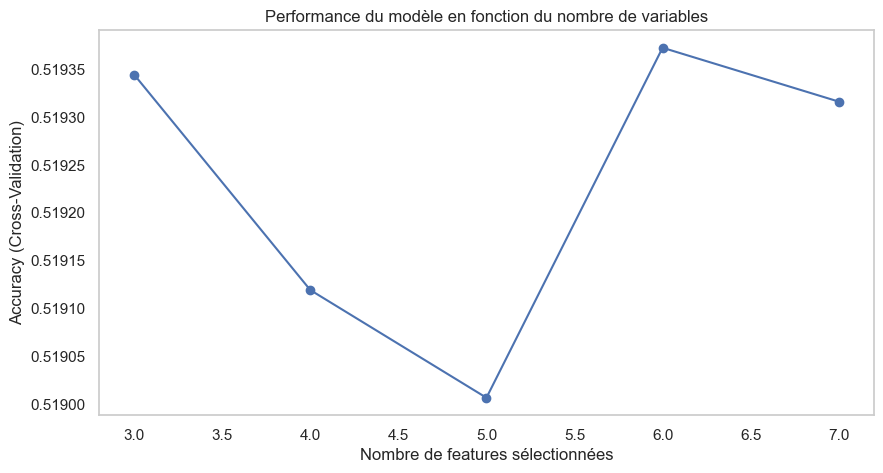


========== ÉTAPE 2 : XGBOOST OPTIMISÉ (Sur 6 vars) ==========
Fold 1 | Acc: 0.5212 | Marché: 0.5229 (Diff: -0.0017) | LogLoss: 0.9873
Fold 2 | Acc: 0.5117 | Marché: 0.5124 (Diff: -0.0008) | LogLoss: 0.9940
Fold 3 | Acc: 0.5241 | Marché: 0.5256 (Diff: -0.0015) | LogLoss: 0.9818


In [3]:
def run_feature_optimization_pipeline(df, all_features, target_col="target", n_splits=3):
    """
    Pipeline complet : 
    1. Sélection des meilleures features via RFECV.
    2. Ré-entraînement de XGBoost sur ce sous-ensemble optimal.
    """
    
    print(f"\n{'='*10} ÉTAPE 1 : SÉLECTION DES FEATURES (RFECV) {'='*10}")
    
    # Préparation
    # On s'assure que les données sont triées temporellement
    df = df.sort_values("MatchDate").reset_index(drop=True)
    X = df[all_features]
    y = df[target_col]

    # Modèle pour la sélection : Random Forest "Léger"
    # Pourquoi RF et pas XGB ici ? 
    # 1. Plus rapide pour l'itération RFECV.
    # 2. Les importances de features sont très corrélées entre RF et XGB.
    selector_model = RandomForestClassifier(
        n_estimators=50, 
        max_depth=5, 
        random_state=42, 
        n_jobs=-1
    )

    # Validation Croisée Temporelle (Indispensable pour ne pas tricher)
    tscv = TimeSeriesSplit(n_splits=n_splits)

    # Lancement du RFECV
    # step=1 : On enlève 1 variable à chaque tour
    # min_features_to_select=3 : On garde au moins 3 variables quoi qu'il arrive
    rfecv = RFECV(
        estimator=selector_model,
        step=1,
        cv=tscv,
        scoring='accuracy', # On optimise l'accuracy pure
        min_features_to_select=3,
        n_jobs=-1
    )
    
    print("Recherche du sous-ensemble optimal en cours... (Cela peut prendre quelques minutes)")
    rfecv.fit(X, y)

    # --- RÉSULTATS DE LA SÉLECTION ---
    optimal_n = rfecv.n_features_
    selected_cols = [f for f, s in zip(all_features, rfecv.support_) if s]
    
    print(f"\n✅ Nombre optimal de features : {optimal_n} (sur {len(all_features)} disponibles)")
    print(f"✅ Features retenues : {selected_cols}")
    
    # Visualisation de la courbe d'apprentissage (Performance vs Nb Features)
    plt.figure(figsize=(10, 5))
    plt.xlabel("Nombre de features sélectionnées")
    plt.ylabel("Accuracy (Cross-Validation)")
    
    # cv_results_['mean_test_score'] contient les scores pour chaque nb de features
    scores = rfecv.cv_results_['mean_test_score']
    # L'axe X commence à min_features (3)
    plt.plot(range(3, 3 + len(scores)), scores, marker='o') 
    plt.title("Performance du modèle en fonction du nombre de variables")
    plt.grid()
    plt.show()

    # --- ÉTAPE 2 : RELANCE DE XGBOOST AVEC LA SÉLECTION ---
    print(f"\n{'='*10} ÉTAPE 2 : XGBOOST OPTIMISÉ (Sur {optimal_n} vars) {'='*10}")
    
    # On utilise une boucle manuelle pour le XGBoost final
    # On augmente un peu la complexité car il y a moins de bruit
    
    final_model = None
    X_subset = df[selected_cols]
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_subset)):
        X_train, y_train = X_subset.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X_subset.iloc[val_idx], y.iloc[val_idx]
        
        # Configuration optimisée pour moins de features
        model = xgb.XGBClassifier(
            n_estimators=600,       # Un peu plus d'arbres
            learning_rate=0.02,     # Apprentissage plus lent et précis
            max_depth=5,            # Profondeur contrôlée
            subsample=0.8,
            colsample_bytree=0.8,
            objective='multi:softprob',
            num_class=3,
            random_state=42,
            n_jobs=-1,
            eval_metric='mlogloss',
            early_stopping_rounds=50
        )
        
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            verbose=False
        )
        
        y_pred = model.predict(X_val)
        y_prob = model.predict_proba(X_val)
        
        acc = accuracy_score(y_val, y_pred)
        ll = log_loss(y_val, y_prob)
        
        # Comparaison Marché (si possible)
        msg_market = ""
        if "ImpProb_Home" in df.columns:
            market_pred = df.loc[val_idx, ["ImpProb_Home", "ImpProb_Draw", "ImpProb_Away"]].idxmax(axis=1).map({
                "ImpProb_Home": 0, "ImpProb_Draw": 1, "ImpProb_Away": 2
            })
            market_acc = accuracy_score(y_val, market_pred)
            diff = acc - market_acc
            msg_market = f" | Marché: {market_acc:.4f} (Diff: {diff:+.4f})"
            
        print(f"Fold {fold+1} | Acc: {acc:.4f}{msg_market} | LogLoss: {ll:.4f}")
        
        if fold == n_splits - 1:
            final_model = model

    return selected_cols, final_model

# --- LANCEMENT ---
# Important : On utilise 'df_tree' (créé précédemment) qui contient les NaN nettoyés
# Et on lui passe 'tree_features' (la liste complète) pour qu'il fasse le tri
opt_features, opt_model = run_feature_optimization_pipeline(df_tree, tree_features, n_splits=3)

### Analyse des Résultats de la Sélection

1.  **La Courbe de Performance :**
    * Si la courbe monte et atteint un plateau rapide (ex: à 4-5 variables), cela confirme que le reste des variables n'est que du bruit.
    * Si la courbe descend quand on ajoute des variables, c'est la preuve formelle de l'overfitting.

2.  **Les "Survivants" :**
    * Regardez quelles variables ont été conservées dans `Features retenues`.
    * Si `HandiSize` ou `Form5Diff` disparaissent, c'est la preuve qu'elles apportaient plus de confusion que d'aide dans ce contexte spécifique.
    * Il est très probable que le modèle ne garde que `ImpProb_Home`, `ImpProb_Away` et `EloDiff`.

3.  **Performance Finale :**
    * Comparez le score du dernier Fold ici avec les 52.20% du XGBoost "brut".
    * Si vous atteignez 52.50% ou 52.60%, l'optimisation a fonctionné : vous avez supprimé le bruit et stabilisé le modèle.